# Car Price Prediction using Machine Learning

### Objective

Develop a machine learning regression model to predict the selling price of used cars based on vehicle attributes. The project includes data preprocessing, exploratory data analysis, feature engineering, model training, and performance evaluation using Python.

In [44]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")



In [45]:
# Load Dataset
df = pd.read_csv("../Data/car_data.csv")

## Dataset Overview

In [46]:
# Dataset Shape
df.shape

(301, 9)

In [47]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [48]:
# Statistical Summary
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [49]:
# Data Types
pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

,Column Name,Data Type
0,Car_Name,str
1,Year,int64
2,Selling_Price,float64
3,Present_Price,float64
4,Driven_kms,int64
5,Fuel_Type,str
6,Selling_type,str
7,Transmission,str
8,Owner,int64


## Data Cleaning 

In [50]:
# Check Missing Values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [51]:
# Check Duplicate Records
df.duplicated().sum()

np.int64(2)

In [52]:
# View Duplicate Records
df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [53]:
# Remove Duplicate Records
df = df.drop_duplicates()
#Check
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics, distribution, and relationships within the dataset before building a machine learning model. 

### Target Variable Analysis

Analyze the distribution of the target variable (`Selling_Price`) to understand its spread, identify common price ranges, detect skewness, and observe potential outliers before model development.

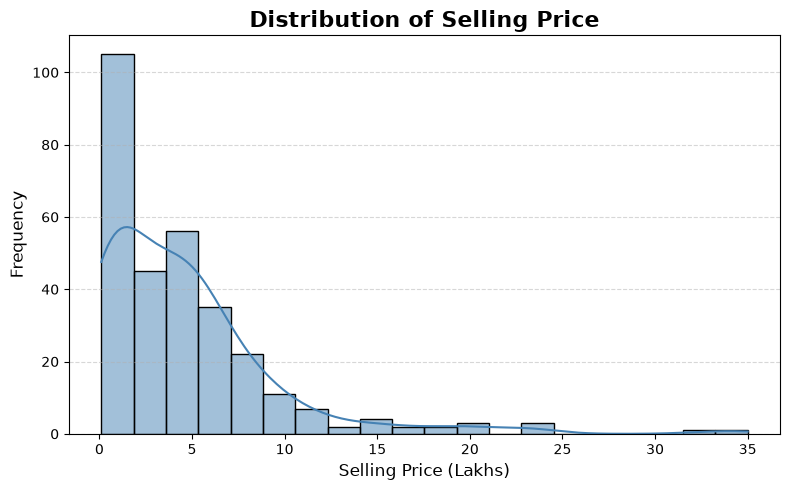

In [54]:
# Distribution of Selling Price

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Selling_Price",
    bins=20,
    kde=True,
    color='steelblue',
    edgecolor='black'
)
plt.title("Distribution of Selling Price",fontsize=16,fontweight='bold')
plt.xlabel("Selling Price (Lakhs)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y',linestyle='--',alpha=0.5)

plt.tight_layout()
plt.show()

### Insights

- Most used cars have a selling price between **₹1–8 lakhs**, indicating that the dataset is dominated by affordable vehicles.
- The distribution is **positively (right) skewed**, with only a few cars having very high selling prices.


### Categorical Variable Analysis

Analyze the distribution of categorical features to understand the frequency of each category and identify any class imbalance in the dataset.

### Fuel Type Distribution

Analyze the distribution of different fuel types to identify the most common fuel category in the dataset.

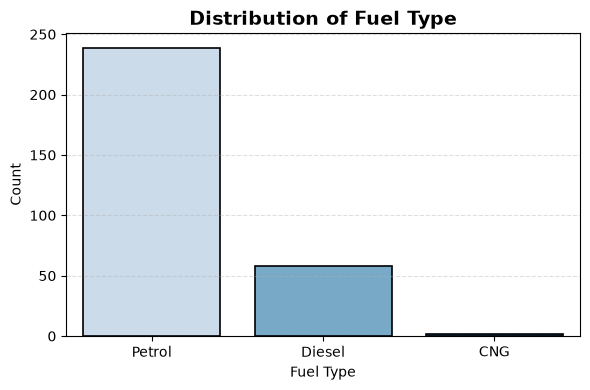

In [55]:
# Fuel Type Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Fuel_Type",
    palette="Blues",
    edgecolor="black",
    linewidth=1.2
)

plt.title("Distribution of Fuel Type", fontsize=14, fontweight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Insights

- Petrol cars dominate the dataset with the highest count.
- Diesel cars are present in moderate numbers, while CNG cars are very rare.

### Transmission Distribution

Analyze the distribution of transmission types to understand whether manual or automatic cars are more common in the dataset.

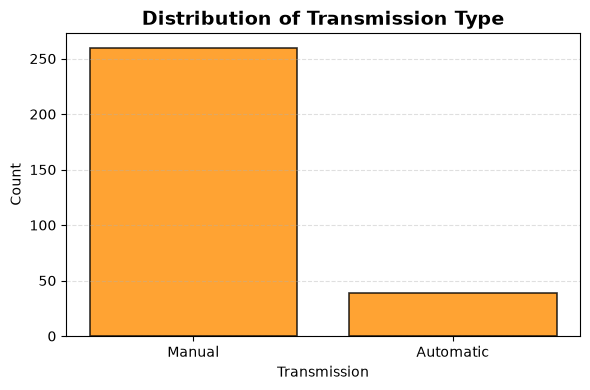

In [56]:
# Transmission Distribution

plt.figure(figsize=(6,4))

plt.bar(
    df["Transmission"].value_counts().index,
    df["Transmission"].value_counts().values,
    color="darkorange",
    edgecolor="black",
    linewidth=1.2,
    alpha=0.8
)

plt.title("Distribution of Transmission Type", fontsize=14, fontweight="bold")
plt.xlabel("Transmission")
plt.ylabel("Count")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Insights

- Manual transmission cars dominate the dataset, while automatic transmission cars are comparatively fewer.
- The dataset is imbalanced, with manual vehicles representing the majority of observations.


### Numerical Variables

Analyze the distribution of numerical features to understand their spread, patterns, and potential outliers.


### Present Price Distribution

Analyze the distribution of the current market price of cars to understand the spread of vehicle prices and identify any skewness or unusual values.

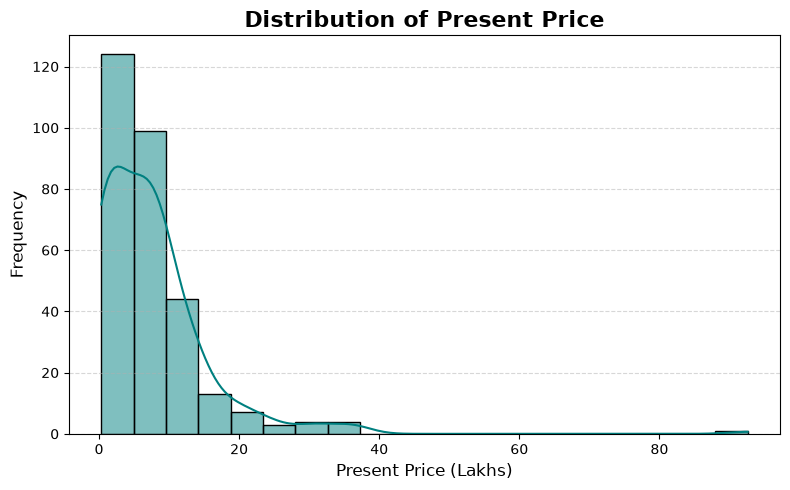

In [57]:
# Distribution of Present Price

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Present_Price",
    bins=20,
    kde=True,
    color="teal",
    edgecolor="black"
)

plt.title("Distribution of Present Price", fontsize=16, fontweight="bold")
plt.xlabel("Present Price (Lakhs)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Insights

- Most cars have a present market price below 10 lakhs, indicating that the dataset is dominated by lower-priced vehicles.
- Only a small number of cars fall in the 20–40 lakh price range, while vehicles priced above 30 lakhs are rare.


### Manufacturing Year Distribution

Analyze the distribution of manufacturing years to understand the age profile of vehicles in the dataset. This helps identify whether the dataset contains predominantly older or newer cars before training the machine learning model.

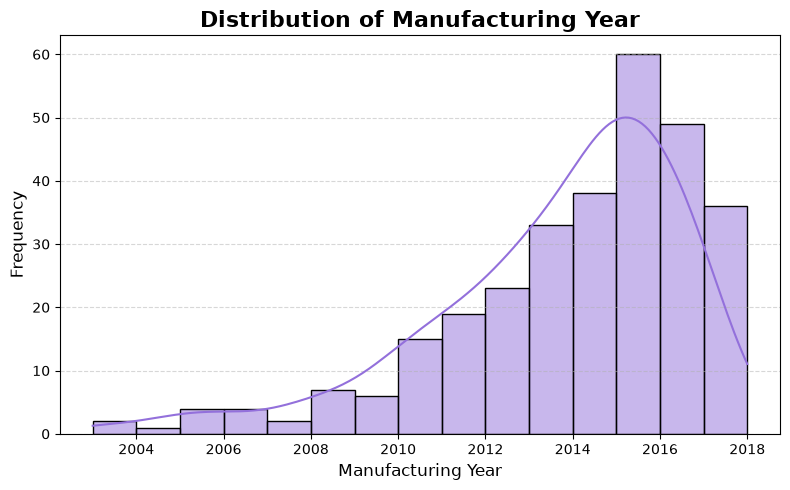

In [58]:
# Distribution of Manufacturing Year

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Year",
    bins=15,
    kde=True,
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Distribution of Manufacturing Year", fontsize=16, fontweight="bold")
plt.xlabel("Manufacturing Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### Insights

- Most vehicles were manufactured between 2013 and 2017, indicating that the dataset is dominated by relatively newer cars.
- Only a small number of vehicles were manufactured before 2010, making older cars less common.

### Kms Driven Distribution

Analyze the distribution of kilometers driven to understand vehicle usage and identify possible outliers.

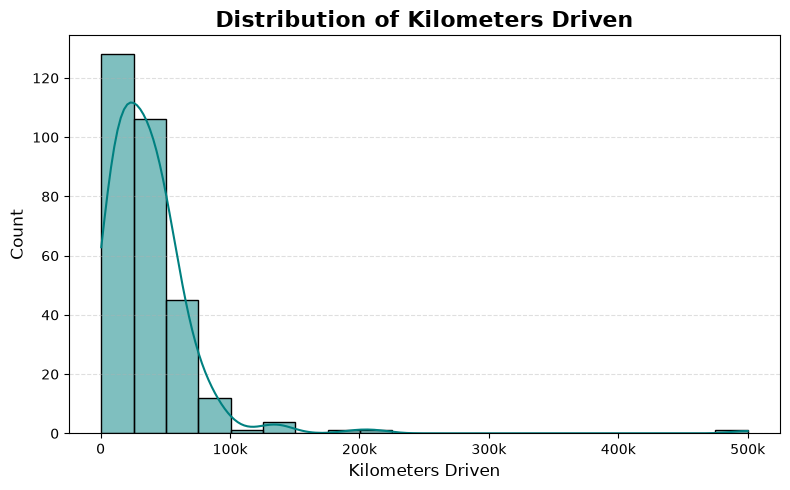

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x = "Driven_kms",
    bins=20,
    kde=True,
    color='teal'
)


plt.title("Distribution of Kilometers Driven",fontsize=16,fontweight="bold")
plt.xlabel("Kilometers Driven", fontsize=12)
plt.ylabel("Count", fontsize=12)

from matplotlib.ticker import FuncFormatter

def format_k(x,pos):
        if x==0:
              return "0"
        else:
              return f'{int(x/1000)}k'


plt.gca().xaxis.set_major_formatter(FuncFormatter(format_k))

plt.grid(axis="y",linestyle='--',alpha=0.4)

plt.tight_layout()
plt.show()

### Insights

- Most cars have been driven less than **100K kilometers**.
- The distribution is **right-skewed**, with a few cars having very high mileage.


## Relationship Analysis

Analyze the relationship between input features and the target variable to identify patterns that influence the selling price.


### Present Price vs Selling Price

Analyze the relationship between the present price and selling price of cars to determine whether present price influences resale value.

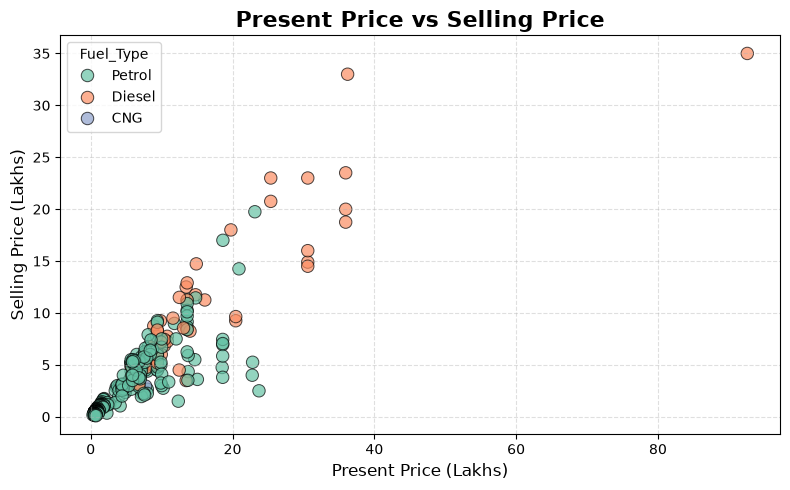

In [60]:
# Present Price vs Selling Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price",
    hue="Fuel_Type",
    palette="Set2",
    s=80,
    edgecolor="black",
    alpha=0.7
)

plt.title(
    "Present Price vs Selling Price",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Present Price (Lakhs)", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Insights

- A strong positive relationship exists between Present Price and Selling Price.
- Most cars are concentrated in the lower price range.
- Diesel cars generally have higher present and selling prices than Petrol and CNG cars.
- A few high-priced cars appear as potential outliers.

### Year vs Selling Price

Analyze the relationship between the manufacturing year and selling price to understand how a car's age affects its resale value.

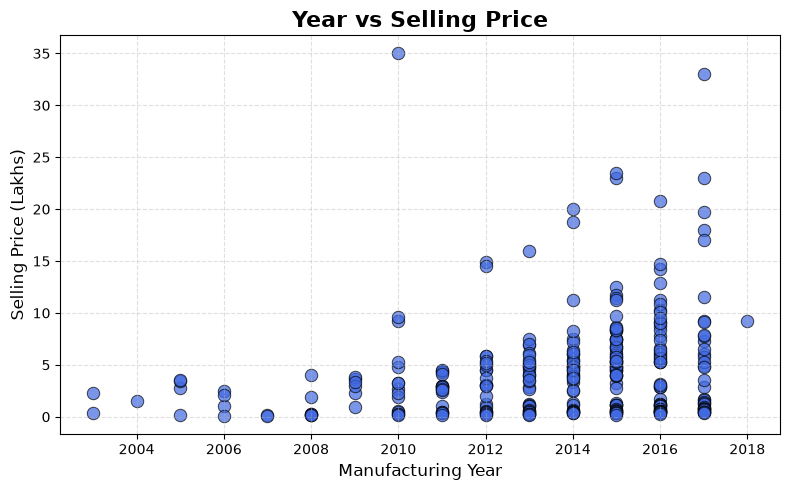

In [61]:
# Year vs Selling Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Year",
    y="Selling_Price",
    color="royalblue",
    edgecolor="black",
    alpha=0.7,
    s=80
)

plt.title(
    "Year vs Selling Price",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Manufacturing Year", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Insights

- Newer cars generally have higher selling prices.
- Most cars are concentrated between recent manufacturing years.


### Kms Driven vs Selling Price

Analyze the relationship between kilometers driven and selling price to understand how vehicle usage affects resale value.

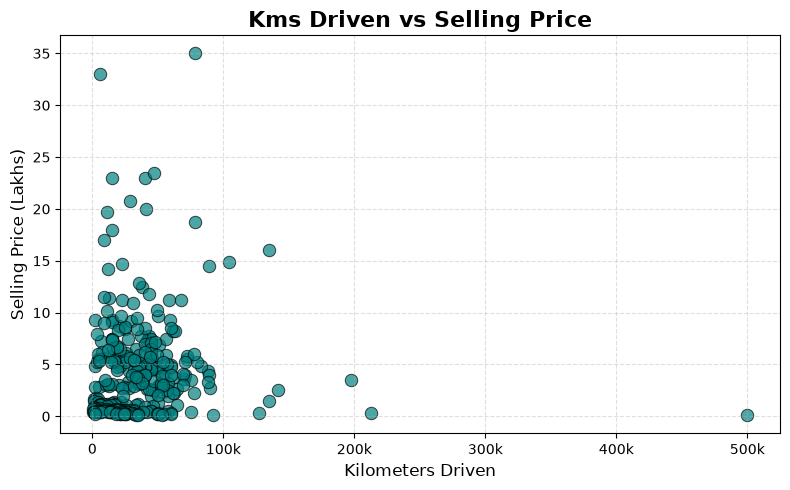

In [62]:
# Kms Driven vs Selling Price

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price",
    color="teal",
    edgecolor="black",
    alpha=0.7,
    s=80
)

plt.title(
    "Kms Driven vs Selling Price",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Kilometers Driven", fontsize=12)
plt.ylabel("Selling Price (Lakhs)", fontsize=12)

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_k))

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### Insights

- Most cars have been driven below **100K kilometers** and have selling prices below **₹10 lakhs**.
- Kilometers driven alone does not show a strong relationship with selling price.
- A few cars have unusually high kilometers driven, indicating potential outliers.

## Correlation Analysis

Analyze the correlation between numerical features to identify their relationships and importance for prediction.

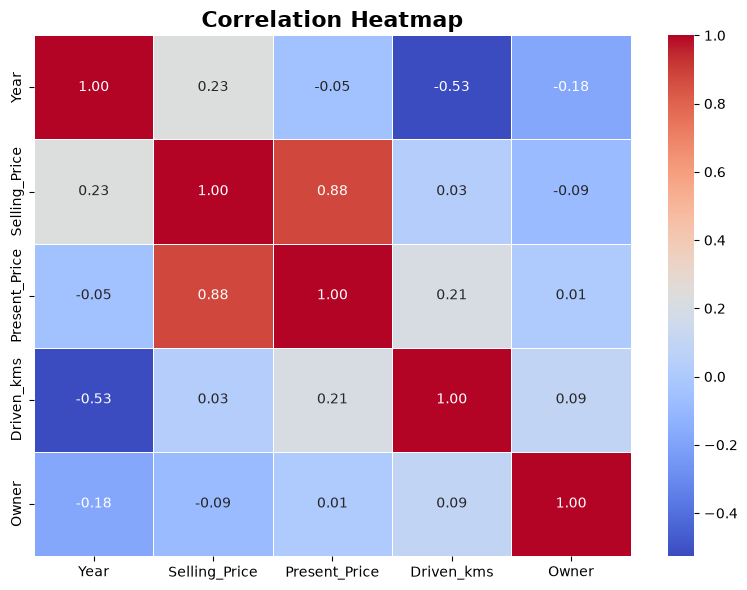

In [63]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Insights

- `Present_Price` has the strongest positive correlation (**0.88**) with `Selling_Price`.
- `Year` shows a weak positive correlation (**0.23**) with `Selling_Price`.
- `Driven_kms` has a very weak correlation (**0.03**) with `Selling_Price`.
- `Year` and `Driven_kms` have a moderate negative correlation (**-0.53**), indicating newer cars generally have lower mileage.


## Feature Engineering

Feature Engineering means creating, changing, or removing columns so the machine learning model can understand the data better and make better predictions.

In [64]:
# Create Car Age
df["Car_Age"] = 2019 - df["Year"]

# Remove the original Year column
df.drop("Year", axis=1, inplace=True)

# Display updated dataset
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,5
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,6
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,2
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,8
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,5


## Categorical Data Encoding

Convert categorical variables into numerical format so that they can be processed by the machine learning model.

In [65]:
# Encode categorical variables
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True,
    dtype=int
)

# Display updated dataset
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,ritz,3.35,5.59,27000,0,5,0,1,0,1
1,sx4,4.75,9.54,43000,0,6,1,0,0,1
2,ciaz,7.25,9.85,6900,0,2,0,1,0,1
3,wagon r,2.85,4.15,5200,0,8,0,1,0,1
4,swift,4.60,6.87,42450,0,5,1,0,0,1


## Prepare Data for Machine Learning

Separate the dataset into input features (`X`) and the target variable (`y`) for model training.

- **X:** Features used to make predictions.
- **y:** Target variable to be predicted.

In [66]:
X = df.drop(["Selling_Price", "Car_Name"], axis=1)

y = df[["Selling_Price"]]

print("X:")
display(X.head())

print("y:")
display(y.head())


X:


,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,5.59,27000,0,5,0,1,0,1
1,9.54,43000,0,6,1,0,0,1
2,9.85,6900,0,2,0,1,0,1
3,4.15,5200,0,8,0,1,0,1
4,6.87,42450,0,5,1,0,0,1


y:


,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


## Train-Test Split

Split the dataset into training and testing sets to train the model and evaluate its performance on unseen data.

In [67]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check the shape
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (239, 8)
X_test : (60, 8)
y_train: (239, 1)
y_test : (60, 1)


## Model Training

Train the machine learning model using the training data to learn the relationship between car features and selling price.

Linear Regression is a supervised machine learning algorithm that learns the relationship between one or more input features and a continuous numerical target, and predicts the target value by fitting the best straight-line relationship through the data.

In [68]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 8)","[[ 0.44,-0. , 0.64,..., 0.69,-1.3 ,-1.57]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Present_Price','Driven_kms','Owner',...,'Fuel_Type_Petrol', 'Selling_type_Individual','Transmission_Manual']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[4.31]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


## Model Prediction

Use the trained Linear Regression model to predict selling prices for unseen test data.

In [69]:
# Make predictions on unseen test data
y_pred = model.predict(X_test)

## Model Evaluation

Evaluate the Linear Regression model by comparing the actual selling prices with the predicted selling prices.

In [70]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values.ravel(),
    "Predicted Price": y_pred.ravel().round(2)
})

comparison.head()

,Actual Price,Predicted Price
0,8.99,7.50
1,8.35,7.79
2,0.45,1.37
3,7.45,7.01
4,5.25,11.17


## Linear Regression Model Evaluation

Evaluate the performance of the Linear Regression model using MAE, MSE, RMSE, and R² Score by comparing the actual and predicted selling prices.

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1.4725457508178643
MSE: 6.373125106260707
R² Score: 0.7527233824220485


## Random Forest Regression

Train a Random Forest Regression model to learn complex, non-linear relationships between car features and selling price.

In [72]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [73]:
# Make predictions using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

In [74]:
comparison_rf = pd.DataFrame({
    "Actual Price": y_test.values.ravel(),
    "Predicted Price": y_pred_rf.ravel().round(2)
})

comparison_rf.head()

,Actual Price,Predicted Price
0,8.99,9.51
1,8.35,8.29
2,0.45,0.44
3,7.45,6.92
4,5.25,17.31


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

MAE: 1.4657233333333344
MSE: 12.31570740600001
RMSE: 3.5093742185751595
R² Score: 0.5221517827346993


## Model Comparison

Compare the performance of Linear Regression and Random Forest Regression using evaluation metrics.

In [76]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "MSE": [mse, mse_rf],
    "RMSE": [rmse, rmse_rf],
    "R² Score": [r2, r2_rf]
})

model_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.472546,6.373125,2.524505,0.752723
1,Random Forest,1.465723,12.315707,3.509374,0.522152


## Select the Best Model


In [77]:
final_model = model

## Make a Prediction for a New Car

In [79]:
new_car = [[
    5.59,   # Present_Price
    27000,  # Driven_kms
    0,      # Owner
    5,      # Car_Age
    0,      # Fuel_Type_Diesel
    1,      # Fuel_Type_Petrol
    0,      # Selling_type_Individual
    0       # Transmission_Manual
]]

predicted_price = final_model.predict(new_car)

print(
    "Predicted Selling Price:",
    round(predicted_price[0].item(), 2),
    "Lakhs"
)

Predicted Selling Price: 5.51 Lakhs
